# 📚 Factor Zoo: 25 Signaux Comptables (Feng, Giglio & Xiu 2020)

**Source**: "Taming the Factor Zoo" (Journal of Finance, 2020)  
**Output**: `data/signals/signals_ALL_v2.parquet` → Format: `[PERMNO, mthdate, portfolio_date, 25 signaux]`

all 25 signals meet Min ≥ 20 firms

---

## SIGNAUX PAR CATÉGORIE

### A. PROFITABILITY (5)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 1 | `gross_profitability` | #88 | (SALE - COGS) / AT | 28.32% |
| 2 | `operating_profitability` | #95 | (REVT - COGS - XSGA) / AT | 50.97% |
| 3 | `return_on_assets` | #82 | NI / AT | 19.68% |
| 4 | `change_asset_turnover` | #72 | Δ(SALE / AT) | 21.65% |
| 5 | `change_profit_margin` | #74 | Δ(NI / SALE) | 19.12% |

### B. INVESTMENT (6)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 6 | `roic` | #70 | (NI - DVC) / (CEQ + DLTT) | 26.53% |
| 7 | `asset_growth` | #92 | Δ AT / AT_lag | 68.72% |
| 8 | `investment_capex` | #53 | CAPX / AT | 30.45% |
| 9 | `capex_inventory_growth` | #81 | (Δ PPEGT + Δ INVT) / AT | 29.95% |
| 10 | `net_share_issues` | #73 | Δ CSHO / CSHO_lag | 26.20% |
| 11 | `capex_growth` | #63 | Δ CAPX / AT | 16.10% |

### C. ACCRUALS & QUALITY (4)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 12 | `sales_growth` | #24 | Δ SALE / SALE_lag | -8.34% |
| 13 | `working_capital_accruals` | #28 | Δ(ACT - CHE - LCT + DLC) / AT_avg | 25.75% |
| 14 | `sales_receivables_gap` | #34 | (Δ SALE - Δ RECT) / AT | 47.59% |
| 15 | `receivables_turnover` | #17 | SALE / RECT | 22.42% |

### D. LIQUIDITY & SOLVENCY (4)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 16 | `operating_leverage` | N/A | (Δ SALE - Δ INVT) / AT | N/A |
| 17 | **`cash_cushion`** | **#86** | **CHE / AT** | **22.22%** |
| 18 | `book_leverage` | #7 | (DLTT + DLC) / SEQ | 13.39% |
| 19 | `change_current_ratio` | #11 | Δ(ACT / LCT) | 14.00% |
| 20 | `debt_capacity` | #71 | (RECT + INVT + PPENT) / AT | 1.31% |

### E. OPERATING EFFICIENCY (4)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 21 | `cash_productivity` | #76 | (SALE + Δ RECT) / CHE | 36.72% |
| 22 | `depreciation_to_ppe` | #18 | DP / PPENT | 10.83% |
| 23 | `change_depreciation` | #19 | Δ DP / AT | 11.90% |
| 24 | `tax_income_ratio` | #56 | TXT / PI | 20.26% |

### F. INTANGIBLES (1)
| # | Variable | Feng ID | Formule | Sharpe |
|---|----------|---------|---------|--------|
| 25 | `asset_turnover` | N/A | SALE / AT | N/A |


In [1]:
# Setup & Signal Calculation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Helper functions
def clean_inf(s):
    s.loc[s.isin([np.inf, -np.inf])] = np.nan
    return s

def calc_ratio(num, denom):
    return clean_inf(num / denom)

# Load data
df = pd.read_parquet('data/signalbaseline/panel_processed.parquet')
df_june = df[df['mthdate'].dt.month == 6].copy().sort_values(['PERMNO', 'mthdate'])

print(f"Dataset: {len(df_june):,} obs | Period: {df_june['mthdate'].min().date()} → {df_june['mthdate'].max().date()}")

# ===== PROFITABILITY =====
df_june['gross_profitability']     = calc_ratio(df_june['sale'] - df_june['cogs'], df_june['at'])
df_june['return_on_assets']        = calc_ratio(df_june['ni'], df_june['at'])
df_june['asset_turnover']          = calc_ratio(df_june['sale'], df_june['at'])
df_june['change_asset_turnover']   = df_june['asset_turnover'] - df_june.groupby('PERMNO')['asset_turnover'].shift(1)
df_june['profit_margin']           = calc_ratio(df_june['ni'], df_june['sale'])
df_june['change_profit_margin']    = df_june['profit_margin'] - df_june.groupby('PERMNO')['profit_margin'].shift(1)
df_june['operating_profitability'] = calc_ratio(df_june['revt'] - df_june['cogs'] - df_june['xsga'], df_june['at'])



# ===== INVESTMENT =====
df_june['at_lag1']                 = df_june.groupby('PERMNO')['at'].shift(1)
df_june['at_avg']                  = (df_june['at'] + df_june['at_lag1']) / 2
df_june['roic']                    = calc_ratio(
    df_june['ni'] - df_june['dvc'],
    df_june['ceq'] + df_june['dltt']
)
df_june['asset_growth']            = calc_ratio(df_june['at'] - df_june['at_lag1'], df_june['at_lag1'])
df_june['investment_capex']        = calc_ratio(df_june['capx'], df_june['at'])  
df_june['ppegt_lag1']              = df_june.groupby('PERMNO')['ppegt'].shift(1)
df_june['invt_lag1']               = df_june.groupby('PERMNO')['invt'].shift(1)
df_june['capex_inventory_growth']  = calc_ratio((df_june['ppegt'] - df_june['ppegt_lag1']) + (df_june['invt'] - df_june['invt_lag1']), df_june['at'])
df_june['csho_lag1']               = df_june.groupby('PERMNO')['csho'].shift(1)
df_june['net_share_issues']        = calc_ratio(df_june['csho'] - df_june['csho_lag1'], df_june['csho_lag1'])
df_june['capex_growth']            = calc_ratio(df_june['capx'] - df_june.groupby('PERMNO')['capx'].shift(1), df_june['at'])
df_june['sale_lag1']               = df_june.groupby('PERMNO')['sale'].shift(1)
df_june['sales_growth']            = calc_ratio(df_june['sale'] - df_june['sale_lag1'], df_june['sale_lag1'])
df_june['sale_lag1']               = df_june.groupby('PERMNO')['sale'].shift(1)
df_june['sales_growth']            = calc_ratio(df_june['sale'] - df_june['sale_lag1'], df_june['sale_lag1'])


# ===== ACCRUALS & QUALITY =====
df_june['wc']                        = (df_june['act'] - df_june['che']) - (df_june['lct'] - df_june['dlc'])
df_june['working_capital_accruals']  = calc_ratio(df_june['wc'] - df_june.groupby('PERMNO')['wc'].shift(1), df_june['at_avg'])
df_june['rect_lag1']                 = df_june.groupby('PERMNO')['rect'].shift(1)
df_june['sales_receivables_gap'] = calc_ratio(
    (df_june['sale'] - df_june['sale_lag1']) - (df_june['rect'] - df_june['rect_lag1']),
    df_june['at']
)
df_june['receivables_turnover']      = calc_ratio(df_june['sale'], df_june['rect'])
df_june['operating_leverage']        = calc_ratio(
    (df_june['sale'] - df_june['sale_lag1']) - (df_june['invt'] - df_june['invt_lag1']),
    df_june['at']
)

# ===== LIQUIDITY & SOLVENCY =====
df_june['cash_cushion']          = calc_ratio(df_june['che'], df_june['at'])
df_june['book_leverage']         = calc_ratio(df_june['dltt'] + df_june['dlc'], df_june['seq'])
df_june['current_ratio']         = calc_ratio(df_june['act'], df_june['lct'])
df_june['change_current_ratio']  = df_june['current_ratio'] - df_june.groupby('PERMNO')['current_ratio'].shift(1)
df_june['quick_ratio']           = calc_ratio(df_june['act'] - df_june['invt'], df_june['lct'])
df_june['debt_capacity'] = calc_ratio(
    df_june['rect'] + df_june['invt'] + df_june['ppent'],
    df_june['at']
)


# ===== OPERATING EFFICIENCY =====
df_june['cash_productivity']    = calc_ratio(df_june['sale'] + (df_june['rect'] - df_june['rect_lag1']), df_june['che'])
df_june['depreciation_to_ppe']  = calc_ratio(df_june['dp'], df_june['ppent'])
df_june['change_depreciation']  = calc_ratio(df_june['dp'] - df_june.groupby('PERMNO')['dp'].shift(1), df_june['at'])
df_june['tax_income_ratio']     = calc_ratio(df_june['txt'], df_june['pi'])

print("✓ 25 signaux calculés")


Dataset: 134,743 obs | Period: 1958-06-30 → 2024-06-30
✓ 25 signaux calculés


In [2]:
# Winsorization, Validation & Export
signals_list = [
    # Profitability (5)
    'gross_profitability', 'operating_profitability', 'return_on_assets', 'change_asset_turnover', 'change_profit_margin',
    # Investment (5)
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth', 'net_share_issues', 'capex_growth',
    # Accruals & Quality (4)
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap', 'receivables_turnover',
    # Liquidity & Solvency (5) - UPDATED: removed change_quick_ratio, added debt_capacity
    'operating_leverage', 'cash_cushion', 'book_leverage', 'debt_capacity', 'change_current_ratio',
    # Operating Efficiency (4)
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation', 'tax_income_ratio',
    # Intangibles (1)
    'asset_turnover'
]


print(f"✓ {len(signals_list)} signaux dans la liste finale")
assert len(signals_list) == 25, f"Erreur: {len(signals_list)} signaux au lieu de 25"


# Winsorize
for sig in signals_list:
    p1, p99 = df_june[sig].quantile(0.01), df_june[sig].quantile(0.99)
    df_june[sig] = df_june[sig].clip(p1, p99)

# Coverage stats
coverage = [(s, df_june[s].notna().mean()*100) for s in signals_list]
df_cov = pd.DataFrame(coverage, columns=['signal', 'coverage_pct']).sort_values('coverage_pct', ascending=False)
avg_cov = df_cov['coverage_pct'].mean()

print("="*80)
print("COVERAGE PAR SIGNAL")
print("="*80)
print(df_cov.to_string(index=False))
print(f"\nMoyenne: {avg_cov:.1f}%")

# Validation
assert avg_cov >= 50, f"Coverage < 50%: {avg_cov:.1f}%"
assert 'cash_cushion' in signals_list, "cash_cushion manquant!"
assert len(signals_list) == 25, f"Nombre != 25: {len(signals_list)}"
print("\n✅ VALIDATION PASSED")

# Export
cols = ['PERMNO', 'mthdate', 'portfolio_date'] + signals_list
df_export = df_june[cols].copy()
output_path = Path('data/signals/signals_ALL.parquet')
output_path.parent.mkdir(exist_ok=True, parents=True)
df_export.to_parquet(output_path)

print(f"\n✅ Sauvegardé: {output_path}")
print(f"   Shape: {df_export.shape} | Période: {df_june['mthdate'].min().date()} → {df_june['mthdate'].max().date()}")
print(f"   Format: IDENTIQUE à signals_ALL.parquet (compatible pipeline 02-05)")

✓ 25 signaux dans la liste finale


COVERAGE PAR SIGNAL
                  signal  coverage_pct
        net_share_issues     66.201584
        return_on_assets     65.017107
          asset_turnover     64.970351
        tax_income_ratio     64.961445
            cash_cushion     64.959961
     gross_profitability     64.926564
                    roic     63.713885
           book_leverage     63.428898
     depreciation_to_ppe     63.374721
           debt_capacity     62.798067
        investment_capex     62.696392
    receivables_turnover     62.323089
            asset_growth     58.619001
 operating_profitability     58.577440
   change_asset_turnover     58.518068
            sales_growth     58.075002
     change_depreciation     58.062385
    change_profit_margin     57.964421
      operating_leverage     57.931766
   sales_receivables_gap     57.010012
       cash_productivity     56.797756
            capex_growth     56.326488
  capex_inventory_growth     56.029627
    change_current_ratio     53.858085
worki

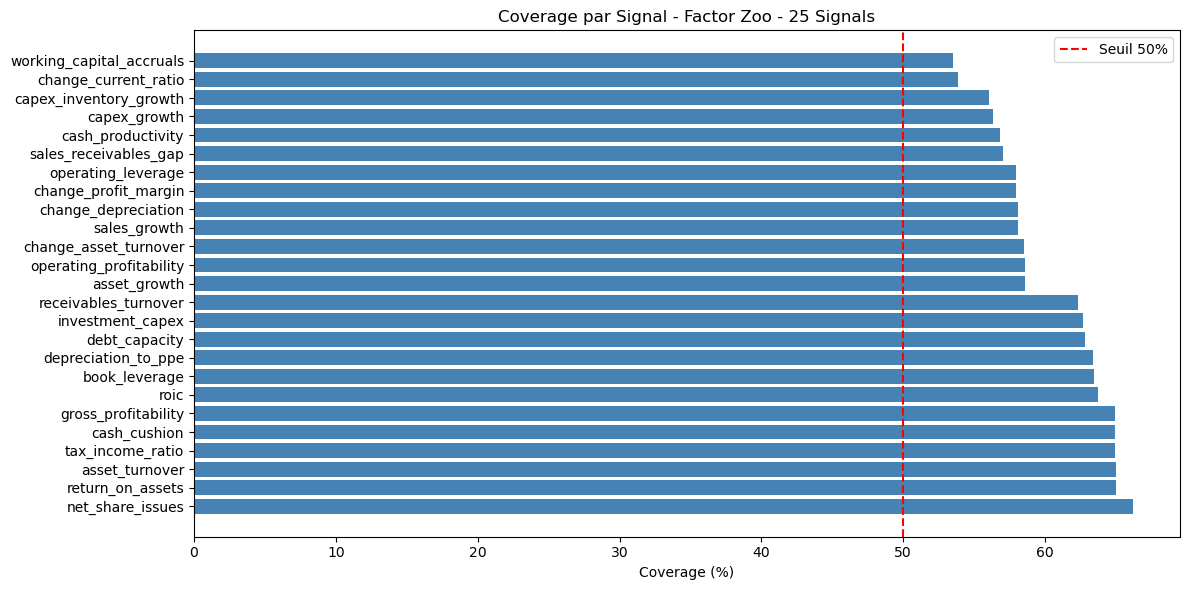

In [3]:
# Coverage visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['darkgreen' if x >= 70 else 'steelblue' if x >= 50 else 'orange' for x in df_cov['coverage_pct']]
ax.barh(df_cov['signal'], df_cov['coverage_pct'], color=colors)
ax.set_xlabel('Coverage (%)')
ax.set_title('Coverage par Signal - Factor Zoo - 25 Signals')
ax.axvline(50, color='red', linestyle='--', label='Seuil 50%')
ax.legend()
plt.tight_layout()
Path('results/figures').mkdir(exist_ok=True, parents=True)
plt.savefig('results/figures/25_Signals_Coverage_Pct.png', dpi=150, bbox_inches='tight')
plt.show()
# print("✓ Plot sauvegardé: results/figures/coverage_factor_zoo_v2.png")

In [4]:
"""
════════════════════════════════════════════════════════════════════════════════
EXPORT LATEX: SIGNAL DEFINITIONS TABLE (Factor Zoo)
════════════════════════════════════════════════════════════════════════════════
Table résumant les 25 signaux : Nom, Formule, ID Factor Zoo, Référence
"""

import pandas as pd
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# SIGNAL DEFINITIONS (Name, Formula, Zoo ID, Reference)
# ════════════════════════════════════════════════════════════════════════════

SIGNAL_DEFINITIONS = [
    # ─────────────────────────────────────────────────────────────────────
    # PANEL A: PROFITABILITY (5)
    # ─────────────────────────────────────────────────────────────────────
    {
        'signal': 'gross_profitability',
        'name': 'Gross Profitability',
        'formula': r'$\frac{\text{SALE} - \text{COGS}}{\text{AT}}$',
        'zoo_id': '#88',
        'reference': 'Novy-Marx (2013)',
    },
    {
        'signal': 'operating_profitability',
        'name': 'Operating Profitability',
        'formula': r'$\frac{\text{REVT} - \text{COGS} - \text{XSGA}}{\text{AT}}$',
        'zoo_id': '#95',
        'reference': 'Fama \& French (2015)',
    },
    {
        'signal': 'return_on_assets',
        'name': 'Return on Assets',
        'formula': r'$\frac{\text{NI}}{\text{AT}}$',
        'zoo_id': '#82',
        'reference': 'Balakrishnan et al. (2010)',
    },
    {
        'signal': 'change_asset_turnover',
        'name': r'$\Delta$ Asset Turnover',
        'formula': r'$\Delta \left( \frac{\text{SALE}}{\text{AT}} \right)$',
        'zoo_id': '#72',
        'reference': 'Soliman (2008)',
    },
    {
        'signal': 'change_profit_margin',
        'name': r'$\Delta$ Profit Margin',
        'formula': r'$\Delta \left( \frac{\text{NI}}{\text{SALE}} \right)$',
        'zoo_id': '#74',
        'reference': 'Soliman (2008)',
    },
    
    # ─────────────────────────────────────────────────────────────────────
    # PANEL B: INVESTMENT (6)
    # ─────────────────────────────────────────────────────────────────────
    {
        'signal': 'roic',
        'name': 'Return on Invested Capital',
        'formula': r'$\frac{\text{NI} - \text{DVC}}{\text{CEQ} + \text{DLTT}}$',
        'zoo_id': '#70',
        'reference': 'Brown \& Rowe (2007)',
    },
    {
        'signal': 'asset_growth',
        'name': 'Asset Growth',
        'formula': r'$\frac{\Delta \text{AT}}{\text{AT}_{t-1}}$',
        'zoo_id': '#92',
        'reference': 'Cooper et al. (2008)',
    },
    {
        'signal': 'investment_capex',
        'name': 'Investment (CapEx)',
        'formula': r'$\frac{\text{CAPX}}{\text{AT}}$',
        'zoo_id': '#53',
        'reference': 'Titman et al. (2004)',
    },
    {
        'signal': 'capex_inventory_growth',
        'name': 'CapEx + Inventory Growth',
        'formula': r'$\frac{\Delta \text{PPEGT} + \Delta \text{INVT}}{\text{AT}}$',
        'zoo_id': '#81',
        'reference': 'Chen \& Zhang (2010)',
    },
    {
        'signal': 'net_share_issues',
        'name': 'Net Share Issuance',
        'formula': r'$\frac{\Delta \text{CSHO}}{\text{CSHO}_{t-1}}$',
        'zoo_id': '#73',
        'reference': 'Pontiff \& Woodgate (2008)',
    },
    {
        'signal': 'capex_growth',
        'name': 'CapEx Growth',
        'formula': r'$\frac{\Delta \text{CAPX}}{\text{AT}}$',
        'zoo_id': '#63',
        'reference': 'Anderson \& Garcia-Feijóo (2006)',
    },
    
    # ─────────────────────────────────────────────────────────────────────
    # PANEL C: ACCRUALS & QUALITY (4)
    # ─────────────────────────────────────────────────────────────────────
    {
        'signal': 'sales_growth',
        'name': 'Sales Growth',
        'formula': r'$\frac{\Delta \text{SALE}}{\text{SALE}_{t-1}}$',
        'zoo_id': '#24',
        'reference': 'Lakonishok et al. (1994)',
    },
    {
        'signal': 'working_capital_accruals',
        'name': 'Working Capital Accruals',
        'formula': r'$\frac{\Delta \text{WC}}{\overline{\text{AT}}}$',
        'zoo_id': '#28',
        'reference': 'Sloan (1996)',
    },
    {
        'signal': 'sales_receivables_gap',
        'name': 'Sales-Receivables Gap',
        'formula': r'$\frac{\Delta \text{SALE} - \Delta \text{RECT}}{\text{AT}}$',
        'zoo_id': '#34',
        'reference': 'Abarbanell \& Bushee (1998)',
    },
    {
        'signal': 'receivables_turnover',
        'name': 'Receivables Turnover',
        'formula': r'$\frac{\text{SALE}}{\text{RECT}}$',
        'zoo_id': '#17',
        'reference': 'Ou \& Penman (1989)',
    },
    
    # ─────────────────────────────────────────────────────────────────────
    # PANEL D: LIQUIDITY & SOLVENCY (5)
    # ─────────────────────────────────────────────────────────────────────
    {
        'signal': 'operating_leverage',
        'name': 'Operating Leverage',
        'formula': r'$\frac{\Delta \text{SALE} - \Delta \text{INVT}}{\text{AT}}$',
        'zoo_id': 'N/A',
        'reference': 'Abarbanell \& Bushee (1998)',
    },
    {
        'signal': 'cash_cushion',
        'name': 'Cash Cushion',
        'formula': r'$\frac{\text{CHE}}{\text{AT}}$',
        'zoo_id': '#86',
        'reference': 'Palazzo (2012)',
    },
    {
        'signal': 'book_leverage',
        'name': 'Book Leverage',
        'formula': r'$\frac{\text{DLTT} + \text{DLC}}{\text{SEQ}}$',
        'zoo_id': '#7',
        'reference': 'Bhandari (1988)',
    },
    {
        'signal': 'change_current_ratio',
        'name': r'$\Delta$ Current Ratio',
        'formula': r'$\Delta \left( \frac{\text{ACT}}{\text{LCT}} \right)$',
        'zoo_id': '#11',
        'reference': 'Ou \& Penman (1989)',
    },
    {
        'signal': 'debt_capacity',
        'name': 'Debt Capacity',
        'formula': r'$\frac{\text{RECT} + \text{INVT} + \text{PPENT}}{\text{AT}}$',
        'zoo_id': '#71',
        'reference': 'Almeida \& Campello (2007)',
    },
    
    # ─────────────────────────────────────────────────────────────────────
    # PANEL E: OPERATING EFFICIENCY (5)
    # ─────────────────────────────────────────────────────────────────────
    {
        'signal': 'cash_productivity',
        'name': 'Cash Productivity',
        'formula': r'$\frac{\text{SALE} + \Delta \text{RECT}}{\text{CHE}}$',
        'zoo_id': '#76',
        'reference': 'Chandrashekar \& Rao (2009)',
    },
    {
        'signal': 'depreciation_to_ppe',
        'name': 'Depreciation/PP\&E',
        'formula': r'$\frac{\text{DP}}{\text{PPENT}}$',
        'zoo_id': '#18',
        'reference': 'Holthausen \& Larcker (1992)',
    },
    {
        'signal': 'change_depreciation',
        'name': r'$\Delta$ Depreciation',
        'formula': r'$\frac{\Delta \text{DP}}{\text{AT}}$',
        'zoo_id': '#19',
        'reference': 'Holthausen \& Larcker (1992)',
    },
    {
        'signal': 'tax_income_ratio',
        'name': 'Tax/Income Ratio',
        'formula': r'$\frac{\text{TXT}}{\text{PI}}$',
        'zoo_id': '#56',
        'reference': 'Lev \& Nissim (2004)',
    },
    {
        'signal': 'asset_turnover',
        'name': 'Asset Turnover',
        'formula': r'$\frac{\text{SALE}}{\text{AT}}$',
        'zoo_id': 'N/A',
        'reference': 'Soliman (2008)',
    },
]

# ════════════════════════════════════════════════════════════════════════════
# CREATE DATAFRAME
# ════════════════════════════════════════════════════════════════════════════

df_signals = pd.DataFrame(SIGNAL_DEFINITIONS)

print("=" * 80)
print("SIGNAL DEFINITIONS TABLE")
print("=" * 80)
print(df_signals[['name', 'zoo_id', 'reference']].to_string(index=False))
print("\n" + "=" * 80)

# ════════════════════════════════════════════════════════════════════════════
# EXPORT LATEX (BOOKTABS + RESIZEBOX)
# ════════════════════════════════════════════════════════════════════════════

latex_dir = Path('results/latex/appendix')
latex_dir.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# LATEX HEADER
# ─────────────────────────────────────────────────────────────────────────────

latex_str = r"""\begin{table}[htbp]
\centering
\caption{Signal Definitions and Data Sources}
\label{tab:signal_definitions}

\resizebox{\textwidth}{!}{%
\begin{tabular}{l l l c l}
\toprule
\textbf{Category} & \textbf{Signal Name} & \textbf{Formula} & \textbf{Zoo ID} & \textbf{Reference} \\
\midrule
"""

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A: PROFITABILITY
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{5}{l}{\textit{Panel A: Profitability}} \\" + "\n"

profitability = df_signals.iloc[:5]
for idx, row in profitability.iterrows():
    latex_str += f" & {row['name']} & {row['formula']} & {row['zoo_id']} & {row['reference']} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B: INVESTMENT
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{5}{l}{\textit{Panel B: Investment}} \\" + "\n"

investment = df_signals.iloc[5:11]
for idx, row in investment.iterrows():
    latex_str += f" & {row['name']} & {row['formula']} & {row['zoo_id']} & {row['reference']} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C: ACCRUALS & QUALITY
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{5}{l}{\textit{Panel C: Accruals \& Quality}} \\" + "\n"

accruals = df_signals.iloc[11:15]
for idx, row in accruals.iterrows():
    latex_str += f" & {row['name']} & {row['formula']} & {row['zoo_id']} & {row['reference']} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D: LIQUIDITY & SOLVENCY
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{5}{l}{\textit{Panel D: Liquidity \& Solvency}} \\" + "\n"

liquidity = df_signals.iloc[15:20]
for idx, row in liquidity.iterrows():
    latex_str += f" & {row['name']} & {row['formula']} & {row['zoo_id']} & {row['reference']} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL E: OPERATING EFFICIENCY
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{5}{l}{\textit{Panel E: Operating Efficiency}} \\" + "\n"

efficiency = df_signals.iloc[20:]
for idx, row in efficiency.iterrows():
    latex_str += f" & {row['name']} & {row['formula']} & {row['zoo_id']} & {row['reference']} \\\\\n"

# ─────────────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────────────

latex_str += r"""\bottomrule
\end{tabular}
}% end resizebox

\medskip

\begin{minipage}{\textwidth}
\footnotesize
\textbf{Notes:} This table defines the 25 fundamental signals employed in this study. Signals are grouped into five economic categories following the asset pricing literature: Profitability, Investment, Accruals \& Quality, Liquidity \& Solvency, and Operating Efficiency. \textit{Formula} reports the mathematical definition using Compustat mnemonics (e.g., AT = Total Assets, SALE = Sales Revenue, NI = Net Income). \textit{Zoo ID} references the factor number in Feng, Giglio, and Xiu (2020), ``Taming the Factor Zoo,'' \textit{Journal of Finance}, 75(3), 1327--1370. ``N/A'' indicates signals constructed from existing variables without direct Zoo correspondence. \textit{Reference} cites the original academic paper introducing each signal. Variables are measured annually at fiscal year-end (June formation). See Appendix B for detailed Compustat variable definitions.
\end{minipage}

\end{table}
"""

# ════════════════════════════════════════════════════════════════════════════
# SAVE LATEX FILE
# ════════════════════════════════════════════════════════════════════════════

output_path = latex_dir / 's01_table_A0_signal_definitions.tex'
output_path.write_text(latex_str)

print("\n✅ LATEX TABLE EXPORTED")
print(f"   📁 {output_path}")
print(f"   📊 Format: booktabs with resizebox (fits page width)")
print(f"   📝 Structure:")
print(f"      • 5 Panels (Profitability, Investment, Accruals, Liquidity, Efficiency)")
print(f"      • Columns: Category, Signal Name, Formula, Zoo ID, Reference")
print(f"      • Total: 25 signals")
print(f"   🔗 Zoo IDs link to Feng, Giglio & Xiu (2020)")
print(f"   📚 Academic citations for each signal")
print("\n" + "=" * 80)

SIGNAL DEFINITIONS TABLE
                      name zoo_id                        reference
       Gross Profitability    #88                 Novy-Marx (2013)
   Operating Profitability    #95            Fama \& French (2015)
          Return on Assets    #82       Balakrishnan et al. (2010)
   $\Delta$ Asset Turnover    #72                   Soliman (2008)
    $\Delta$ Profit Margin    #74                   Soliman (2008)
Return on Invested Capital    #70             Brown \& Rowe (2007)
              Asset Growth    #92             Cooper et al. (2008)
        Investment (CapEx)    #53             Titman et al. (2004)
  CapEx + Inventory Growth    #81             Chen \& Zhang (2010)
        Net Share Issuance    #73       Pontiff \& Woodgate (2008)
              CapEx Growth    #63 Anderson \& Garcia-Feijóo (2006)
              Sales Growth    #24         Lakonishok et al. (1994)
  Working Capital Accruals    #28                     Sloan (1996)
     Sales-Receivables Gap    #34    